In [1]:
import sys
import vaex
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")
latex_img_path = "../thesis/assets/generated/"
latex_tex_path = "../thesis/tex/generated/"

from solarboat_model.utils.plot import figsize, config_matplotlib, fig_save_and_show

config_matplotlib()

# Choosing the resampling frequency


In [2]:
from collections import Counter, defaultdict
from glob import glob


def summarize_dt_seconds(dt_seconds):
    if not dt_seconds:
        return None
    arr = np.array(dt_seconds, dtype=float)
    return {
        "n": int(arr.size),
        "median_s": float(np.median(arr)),
        "p90_s": float(np.quantile(arr, 0.90)),
        "min_s": float(np.min(arr)),
        "max_s": float(np.max(arr)),
    }


def hz_from_dt(median_s):
    if median_s is None or median_s <= 0:
        return None
    return float(1.0 / median_s)


def estimate_signal_frequencies(
    paths_glob,
    signals,
    chunk_size=500_000,
    max_samples_per_signal=200_000,
    dt_round_ms=10,
):
    files = sorted(glob(paths_glob))
    if not files:
        raise FileNotFoundError(f"No files matched: {paths_glob}")
    # per-signal state
    last_ts_nonnull = {s: None for s in signals}
    last_ts_change = {s: None for s in signals}
    last_val = {s: None for s in signals}
    dt_nonnull_samples = defaultdict(list)
    dt_change_samples = defaultdict(list)
    dt_nonnull_hist = {s: Counter() for s in signals}
    dt_change_hist = {s: Counter() for s in signals}
    n_nonnull = Counter()
    n_change = Counter()
    cols = ["timestamp"] + list(signals)
    for f in files:
        reader = vaex.open(f).to_pandas_df(chunk_size=chunk_size)
        for _, _, chunk in reader:
            # Keep only needed cols; some signals might not exist in all files
            available = [c for c in cols if c in chunk.columns]
            if "timestamp" not in available:
                continue
            chunk = chunk[available]
            ts = pd.to_datetime(chunk["timestamp"])
            for s in signals:
                if s not in chunk.columns:
                    continue
                x = chunk[s]
                # If duplicate column names exist, pandas returns a DataFrame here.
                if isinstance(x, pd.DataFrame):
                    x = x.iloc[:, 0]
                ok = x.notna()
                if not ok.to_numpy().any():
                    continue
                ts_ok = ts[ok]
                x_ok = x[ok]
                # -------- non-null sample-to-sample dt (message/update rate proxy)
                n_nonnull[s] += int(ok.sum())
                prev = last_ts_nonnull[s]
                tvals = ts_ok.values
                if prev is not None:
                    dt0 = (tvals[0] - prev) / np.timedelta64(1, "s")
                    if len(dt_nonnull_samples[s]) < max_samples_per_signal:
                        dt_nonnull_samples[s].append(float(dt0))
                    dt_nonnull_hist[s][
                        int(round(dt0 * 1000 / dt_round_ms) * dt_round_ms)
                    ] += 1
                if len(tvals) >= 2:
                    dts = (tvals[1:] - tvals[:-1]) / np.timedelta64(1, "s")
                    # sample a prefix to cap memory
                    remaining = max_samples_per_signal - len(dt_nonnull_samples[s])
                    take = int(min(remaining, dts.size))
                    if take > 0:
                        dt_nonnull_samples[s].extend([float(v) for v in dts[:take]])
                    for v in dts[
                        : min(dts.size, 50_000)
                    ]:  # cap histogram work per chunk
                        ms = int(round(float(v) * 1000 / dt_round_ms) * dt_round_ms)
                        dt_nonnull_hist[s][ms] += 1
                last_ts_nonnull[s] = tvals[-1]
                # -------- change-to-change dt (effective change rate proxy)
                # Compare consecutive values (within this non-null subseries)
                xvals = x_ok.values
                # boolean mask of changes relative to previous value seen
                changes = np.ones_like(xvals, dtype=bool)
                if last_val[s] is not None:
                    changes[0] = xvals[0] != last_val[s]
                if xvals.size >= 2:
                    changes[1:] = xvals[1:] != xvals[:-1]
                if changes.any():
                    idx = np.flatnonzero(changes)
                    n_change[s] += int(idx.size)
                    # dt between consecutive changes, including across chunk boundary
                    prevc = last_ts_change[s]
                    change_ts = tvals[idx]
                    if prevc is not None:
                        dtc0 = (change_ts[0] - prevc) / np.timedelta64(1, "s")
                        if len(dt_change_samples[s]) < max_samples_per_signal:
                            dt_change_samples[s].append(float(dtc0))
                        dt_change_hist[s][
                            int(round(dtc0 * 1000 / dt_round_ms) * dt_round_ms)
                        ] += 1
                    if idx.size >= 2:
                        dcs = (change_ts[1:] - change_ts[:-1]) / np.timedelta64(1, "s")
                        remaining = max_samples_per_signal - len(dt_change_samples[s])
                        take = int(min(remaining, dcs.size))
                        if take > 0:
                            dt_change_samples[s].extend([float(v) for v in dcs[:take]])
                        for v in dcs[: min(dcs.size, 50_000)]:
                            ms = int(round(float(v) * 1000 / dt_round_ms) * dt_round_ms)
                            dt_change_hist[s][ms] += 1
                    last_ts_change[s] = change_ts[-1]
                last_val[s] = xvals[-1]
    rows = []
    for s in signals:
        nonnull = summarize_dt_seconds(dt_nonnull_samples[s])
        change = summarize_dt_seconds(dt_change_samples[s])
        mode_ms_nonnull = (
            dt_nonnull_hist[s].most_common(1)[0][0] if dt_nonnull_hist[s] else None
        )
        mode_ms_change = (
            dt_change_hist[s].most_common(1)[0][0] if dt_change_hist[s] else None
        )
        rows.append(
            {
                "signal": s,
                "n_nonnull": int(n_nonnull[s]),
                "nonnull_mode_ms": mode_ms_nonnull,
                "nonnull_median_s": None if nonnull is None else nonnull["median_s"],
                "nonnull_p90_s": None if nonnull is None else nonnull["p90_s"],
                "nonnull_hz_est": (
                    None if nonnull is None else hz_from_dt(nonnull["median_s"])
                ),
                "n_changes": int(n_change[s]),
                "change_mode_ms": mode_ms_change,
                "change_median_s": None if change is None else change["median_s"],
                "change_p90_s": None if change is None else change["p90_s"],
                "change_hz_est": (
                    None if change is None else hz_from_dt(change["median_s"])
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["nonnull_median_s", "signal"], na_position="last"
    )


def plot_signal_hz_bars(df_rates, sort_by="nonnull_hz_est", max_signals=None):
    d = df_rates.copy()

    d = d.sort_values(sort_by, ascending=True)
    if max_signals is not None:
        d = d.tail(max_signals)
    y = np.arange(len(d))
    h = 0.3
    fig = plt.figure(figsize=figsize())

    plt.barh(y - h / 2, d["change_hz_est"], height=h, label="Mudança")
    plt.barh(y + h / 2, d["nonnull_hz_est"], height=h, label="Envio")
    plt.yticks(y, d["signal"])
    plt.xlabel("Frequency [Hz]")
    plt.grid(True, axis="x", alpha=0.3)

    return fig

In [3]:
def col(module: str, topic: str, byte: str) -> str:
    separator = "__"
    return separator.join([module, topic, byte])


# Module name to system variable name mapper
number_of_mppts = 4
number_of_battery_cells = 3
number_of_mcbs = 2

main_signals = [
    "MCS19__BAT__AVG",
    "MSC19_1__ADC__AVG",
    "MSC19_2__ADC__AVG",
    "MSC19_3__ADC__AVG",
    "MSC19_4__ADC__AVG",
    "MSC19_5__ADC__AVG",
    "MAM19__STATE__STATE",
    "MAM19__MOTOR__D",
    "MSWI19__MOTOR__D",
    "MIC19__MOTOR__D",
    "MIC19__MOTOR__MOTOR",
    "MIC19__MCS__BOAT_ON",
    "MT19__RPM__AVG",
]

secondary_signals = [
    "MCB19_1__MEASUREMENTS__INPUT_VOLTAGE",
    "MCB19_2__MEASUREMENTS__INPUT_VOLTAGE",
    "MCC19_1__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_2__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_3__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MSC19_4__STATE__STATE",
    "MSC19_5__STATE__STATE",
    "MSWI19__MOTOR__MOTOR",
    "MSWI19__MCS__BOAT_ON",
    "MCC19_1__MEASUREMENTS__INPUT_VOLTAGE",
    "MCC19_2__MEASUREMENTS__INPUT_VOLTAGE",
    "MCC19_3__MEASUREMENTS__INPUT_VOLTAGE",
    "MCC19_4__MEASUREMENTS__INPUT_VOLTAGE",
    "MCC19_1__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_2__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_3__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_4__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_1__MEASUREMENTS__INPUT_CURRENT",
    "MCC19_2__MEASUREMENTS__INPUT_CURRENT",
    "MCC19_3__MEASUREMENTS__INPUT_CURRENT",
    "MCC19_4__MEASUREMENTS__INPUT_CURRENT",
    "MCC19_1__MEASUREMENTS__DT",
    "MCC19_2__MEASUREMENTS__DT",
    "MCC19_3__MEASUREMENTS__DT",
    "MCC19_4__MEASUREMENTS__DT",
    "MCB19_1__MEASUREMENTS__INPUT_VOLTAGE",
    "MCB19_2__MEASUREMENTS__INPUT_VOLTAGE",
    "MCB19_1__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCB19_2__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCB19_1__MEASUREMENTS__OUTPUT_CURRENT",
    "MCB19_2__MEASUREMENTS__OUTPUT_CURRENT",
    "MCB19_1__MEASUREMENTS__DT",
    "MCB19_2__MEASUREMENTS__DT",
]

,signal,n_nonnull,nonnull_mode_ms,nonnull_median_s,nonnull_p90_s,nonnull_hz_est,n_changes,change_mode_ms,change_median_s,change_p90_s,change_hz_est
11,MIC19__MCS__BOAT_ON,505358,40,0.038527,0.051312,25.955815,37,20,0.090264,974.024793,11.078666
9,MIC19__MOTOR__D,505369,40,0.038528,0.051307,25.955173,19397,40,0.059000,1.370975,16.949148
10,MIC19__MOTOR__MOTOR,505369,40,0.038528,0.051307,25.955173,29,20,0.044542,1145.557558,22.450757
12,MT19__RPM__AVG,434630,50,0.049900,0.049969,20.040154,1560,1000,0.998220,2.046801,1.001783
4,MSC19_4__ADC__AVG,129457,70,0.073205,0.079868,13.660270,359,150,0.117173,0.305077,8.534386
1,MSC19_1__ADC__AVG,289797,70,0.073211,0.079872,13.659158,18199,70,0.079879,0.672274,12.518928
3,MSC19_3__ADC__AVG,289800,70,0.073211,0.079870,13.659158,59180,70,0.079882,0.525826,12.518479
5,MSC19_5__ADC__AVG,289861,70,0.073212,0.079870,13.658980,6195,70,0.073262,0.226355,13.649645
2,MSC19_2__ADC__AVG,289762,70,0.073214,0.079873,13.658624,25211,70,0.079883,0.452641,12.518293
8,MSWI19__MOTOR__D,216882,100,0.099980,0.100077,10.002013,2150,100,0.099978,0.318317,10.002180


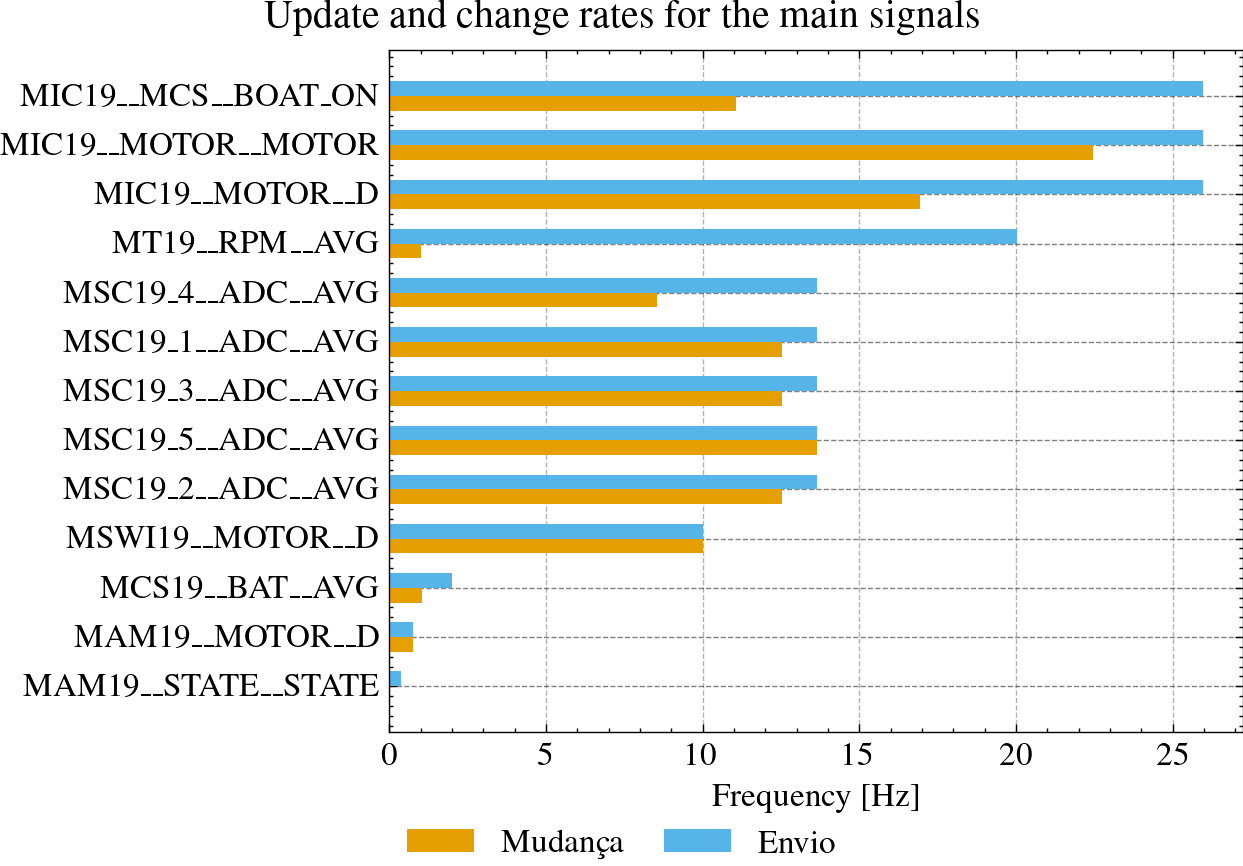

In [4]:
df_main_signals_rates = estimate_signal_frequencies(
    paths_glob="../data/parsed/sparse/candump-2020-02-01_064222.log_combined_chunk_*.hdf5",
    signals=main_signals,
)
display(df_main_signals_rates)

fig_save_and_show(
    filename=f"{latex_img_path}/main_signals_update_and_change_rate.pdf",
    save_title="Taxas de envio e de mudança dos sinais principais",
    show_title="Update and change rates for the main signals",
    ncol=2,
    fig=plot_signal_hz_bars(df_main_signals_rates),
)

In [5]:
df_secondary_signals_rates = estimate_signal_frequencies(
    paths_glob="../data/parsed/sparse/candump-2020-02-01_064222.log_combined_chunk_*.hdf5",
    signals=secondary_signals,
)
df_secondary_signals_rates.describe()

,n_nonnull,nonnull_mode_ms,nonnull_median_s,nonnull_p90_s,nonnull_hz_est,n_changes,change_mode_ms,change_median_s,change_p90_s,change_hz_est
count,3.300000e+01,33.000000,33.000000,33.000000,33.000000,3.300000e+01,21.000000,21.000000,21.000000,21.000000
mean,1.527785e+06,58.787879,0.060643,0.073124,312.754718,1.085011e+06,9.523810,0.009921,0.030315,382.776820
std,1.079701e+06,148.487322,0.148458,0.145467,256.361974,1.150797e+06,15.961263,0.013987,0.023803,224.759962
min,1.570400e+04,0.000000,0.001879,0.021999,1.633005,1.000000e+00,0.000000,0.001885,0.022013,20.283602
25%,6.019710e+05,0.000000,0.001890,0.022003,20.316122,1.000000e+00,0.000000,0.001904,0.022020,41.997638
50%,1.706905e+06,0.000000,0.001894,0.022006,527.983941,7.125470e+05,0.000000,0.001939,0.022028,515.714065
75%,1.719177e+06,50.000000,0.049222,0.049439,529.116207,1.570225e+06,30.000000,0.023811,0.025702,525.194223
max,3.422228e+06,610.000000,0.612368,0.619025,532.204775,3.164531e+06,50.000000,0.049301,0.104805,530.454451


# Resampled dataset timestamp verification


In [6]:
import sys
import vaex
import pandas as pd

sys.path.append("../")

PATH = f"../data/parsed/sparse/candump-2020-02-01_064223.log_combined_chunk_*.hdf5"

SIGNAL = "MT19__RPM__AVG"

df = vaex.open(PATH).to_pandas_df()[["timestamp", SIGNAL]].dropna()

print("min/max:", df["timestamp"].min(), df["timestamp"].max())
dt = df["timestamp"].diff()
print("unique dt (top 5):", dt.value_counts().head())
print("backwards:", int((dt < pd.Timedelta(0)).sum()))
print("unique lenght: ", len(dt.unique()))

min/max: 2020-02-01 13:06:36.436000109 2020-02-01 21:13:20.419195951
unique dt (top 5): timestamp
0 days 00:00:00.049921036    6271
0 days 00:00:00.049922943    5911
0 days 00:00:00.049916029    5842
0 days 00:00:00.049920082    5635
0 days 00:00:00.049921989    4938
Name: count, dtype: int64
backwards: 5
unique lenght:  43882


In [7]:
PERIOD = "1s"
PATH = f"../data/parsed/{PERIOD}/candump-2020-02-01_064223.log_combined_chunk_*.hdf5"

SIGNAL = "MT19__RPM__AVG"

df = vaex.open(PATH).to_pandas_df()[["timestamp", SIGNAL]].dropna()

print("min/max:", df["timestamp"].min(), df["timestamp"].max())
dt = df["timestamp"].diff()
print("unique dt (top 5):", dt.value_counts().head())
print("backwards:", int((dt < pd.Timedelta(0)).sum()))
print("unique lenght: ", len(dt.unique()))

expected = int((df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(PERIOD))
actual = df["timestamp"].nunique() - 1
print("missing steps (approx):", expected - actual)

min/max: 2020-02-01 13:06:36 2020-02-01 21:13:20
unique dt (top 5): timestamp
0 days 00:00:01    29204
0 days 00:00:00       13
Name: count, dtype: int64
backwards: 0
unique lenght:  3
missing steps (approx): 0


In [8]:
import sys
import vaex
import pandas as pd

sys.path.append("../")

PERIOD = "50ms"
PATH = f"../data/parsed/{PERIOD}/candump-2020-02-01_064223.log_combined_chunk_*.hdf5"

SIGNAL = "MT19__RPM__AVG"

df = vaex.open(PATH).to_pandas_df()[["timestamp", SIGNAL]].dropna()

print("min/max:", df["timestamp"].min(), df["timestamp"].max())
dt = df["timestamp"].diff()
print("unique dt (top 5):", dt.value_counts().head())
print("backwards:", int((dt < pd.Timedelta(0)).sum()))
print("unique lenght: ", len(dt.unique()))

expected = int((df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(PERIOD))
actual = df["timestamp"].nunique() - 1
print("missing steps (approx):", expected - actual)

min/max: 2020-02-01 13:06:36.400000 2020-02-01 21:13:20.400000
unique dt (top 5): timestamp
0 days 00:00:00.050000    584080
0 days 00:00:00               13
Name: count, dtype: int64
backwards: 0
unique lenght:  3
missing steps (approx): 0


## Choosing RPM signal smoothing


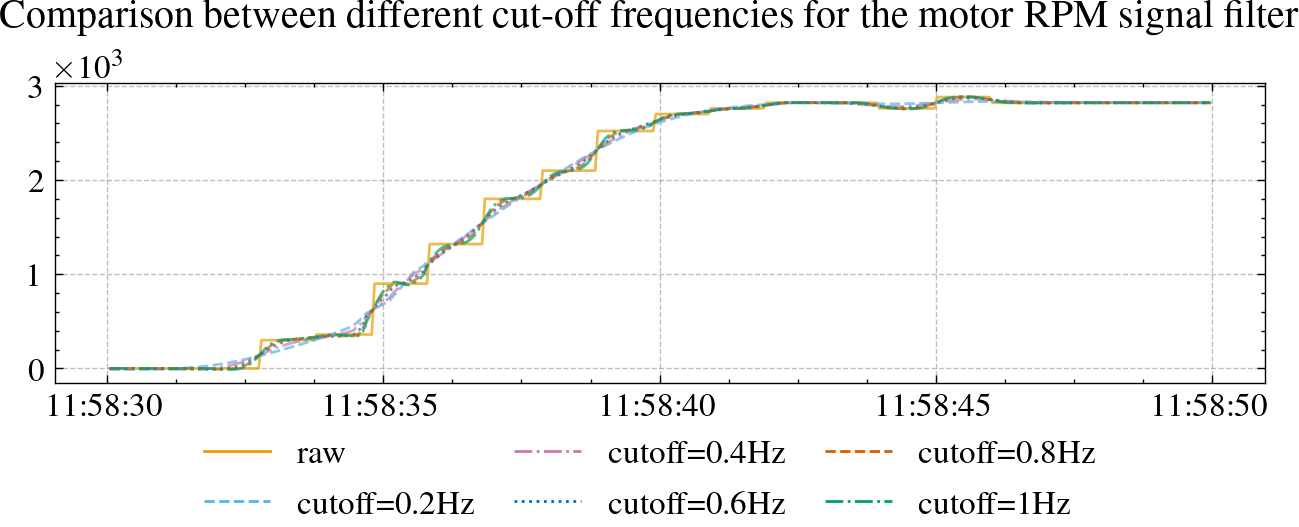

In [ ]:
# 1) Load RPM at 50 ms (your existing resampled output)

import vaex
import pandas as pd

PATH_RAW = "../data/parsed/sparse/candump-2020-02-*.log_combined_chunk_*.hdf5"
RPM_COL = "MT19__RPM__AVG"
df = vaex.open(PATH_RAW).to_pandas_df()[["timestamp", RPM_COL]].dropna()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()
t_start = pd.Timestamp("2020-02-02 11:58:30")
t_end = pd.Timestamp("2020-02-02 11:58:50")
rpm = df.loc[t_start:t_end, RPM_COL].astype(float)

# 2) Zero-phase low-pass smoothing (Butterworth + filtfilt)
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt


def smooth_rpm_filtfilt(
    rpm_series: pd.Series,
    fs_hz: float,
    cutoff_hz: float = 1.5,
    order: int = 2,
) -> pd.Series:
    """
    Zero-phase low-pass filter for RPM on a uniform time grid.
    Assumes rpm_series has no gaps (or small gaps already filled).
    """
    x = rpm_series.to_numpy(dtype=float)
    # Keep NaNs out of filtfilt: interpolate short gaps, then backfill any edge NaNs
    s = pd.Series(x, index=rpm_series.index)
    s = s.interpolate(limit_area="inside", limit=10).ffill().bfill()
    x = s.to_numpy(dtype=float)
    # Butterworth low-pass
    nyq = 0.5 * fs_hz
    wn = cutoff_hz / nyq
    b, a = butter(order, wn, btype="low")
    y = filtfilt(b, a, x)
    return pd.Series(y, index=rpm_series.index, name=rpm_series.name)


# 3) How to tune cutoff_hz
# - Start with cutoff_hz = 1.0 to 2.5 Hz at 20 Hz sampling.
# - Lower cutoff → smoother (more “inertia”), but can flatten real transients.
# - Higher cutoff → keeps more detail, but retains quantization wiggles.
# If you want a quick sweep to choose visually:
fig = plt.figure(figsize=figsize(subplots=(0.5, 1)))
plt.plot(rpm.index, rpm.values, alpha=0.7, label="raw", linewidth=1)
for cutoff in [0.2, 0.4, 0.6, 0.8, 1]:
    y = smooth_rpm_filtfilt(rpm, fs_hz=20.0, cutoff_hz=cutoff, order=2)
    plt.plot(y.index, y.values, label=f"cutoff={cutoff}Hz", alpha=0.7, linewidth=1)
plt.grid(True, alpha=0.25)
fig_save_and_show(
    filename=f"{latex_img_path}/resampling_rpm_filtering_comparison.pdf",
    save_title="Comparação entre diferentes frequências de corte para o filtro do sinal de RPM do motor",
    show_title="Comparison between different cut-off frequencies for the motor RPM signal filter",
    ncol=3,
)

## Verification of different resampling rates


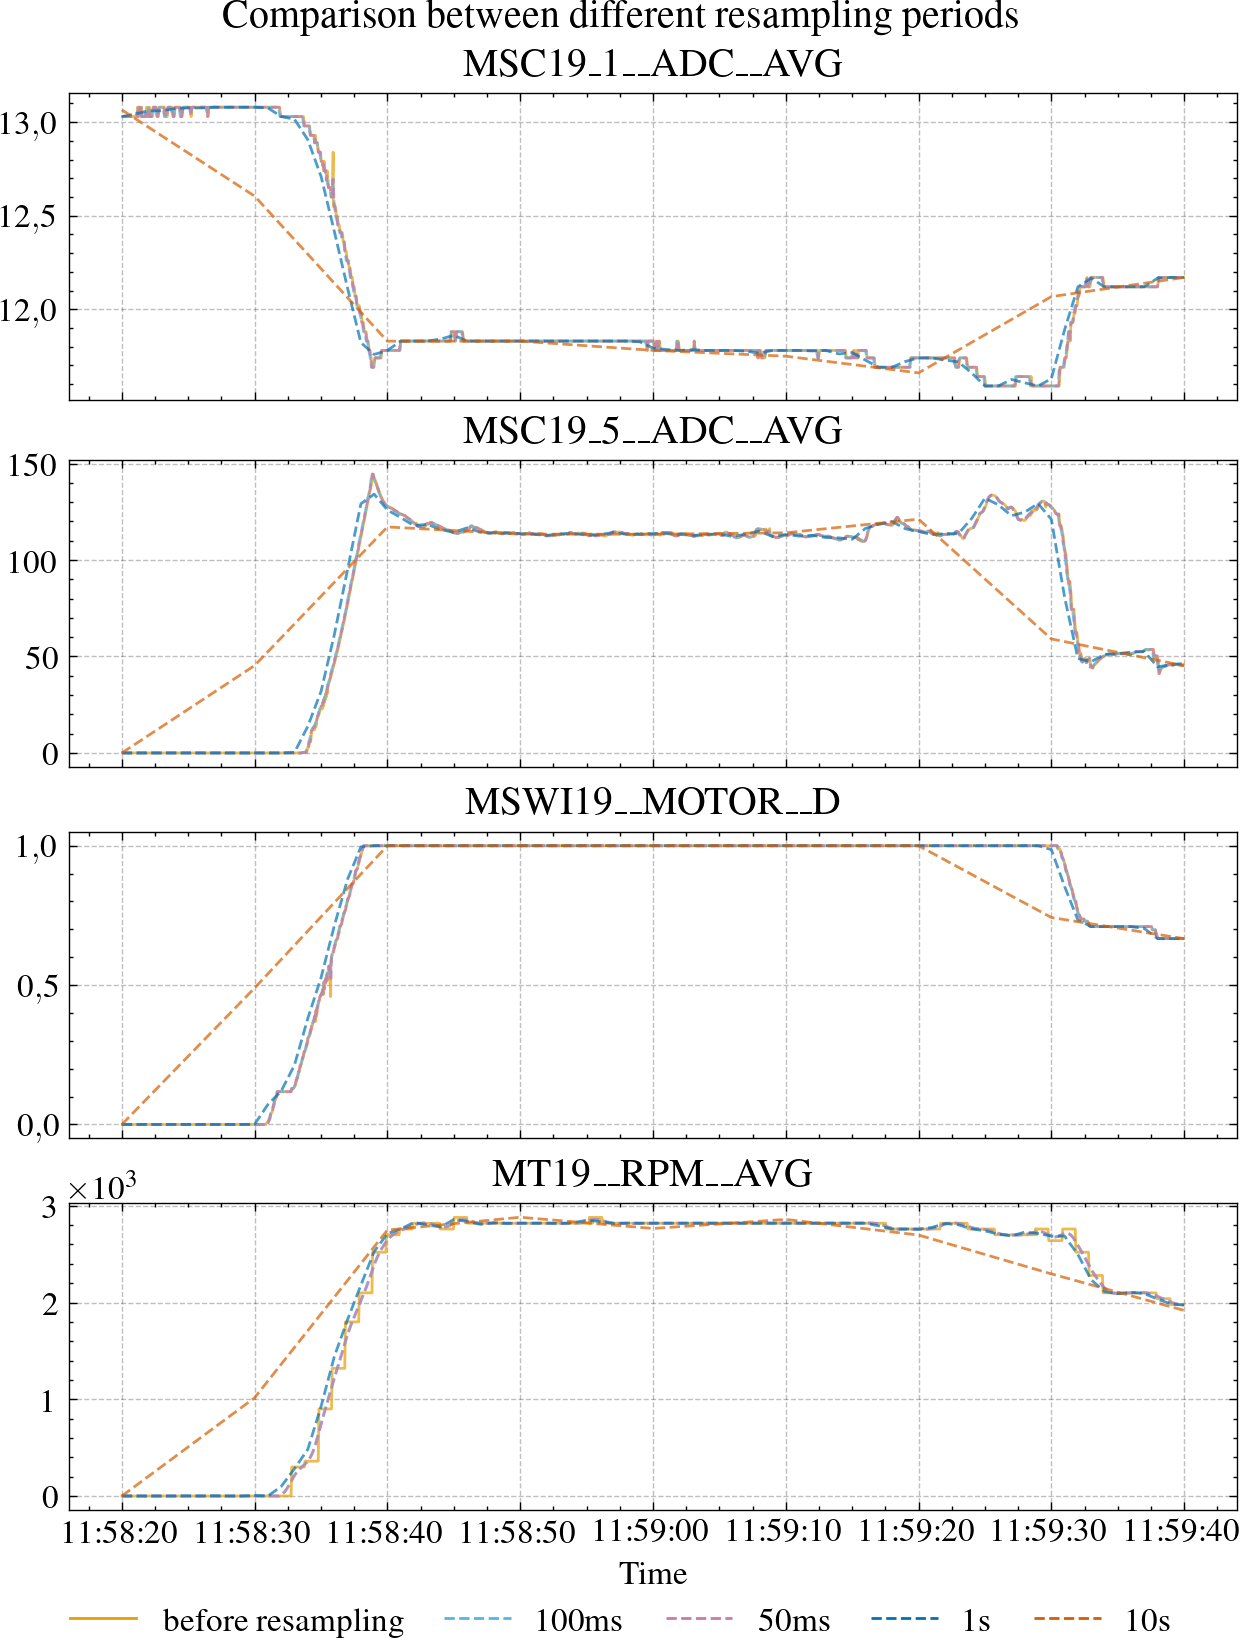

In [ ]:
import matplotlib.pyplot as plt

signals = [
    "MSC19_1__ADC__AVG",
    "MSC19_5__ADC__AVG",
    "MSWI19__MOTOR__D",
    "MT19__RPM__AVG",
]

t_start = pd.Timestamp("2020-02-02 11:58:20")
t_end = pd.Timestamp("2020-02-02 11:59:40")

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_combined_chunk_*.hdf5"
df1 = vaex.open(PATH1)[["timestamp", *signals]].to_pandas_df()
df1["timestamp"] = pd.to_datetime(df1["timestamp"])
df1 = df1.set_index("timestamp").sort_index()
df1 = df1.loc[(df1.index >= t_start) & (df1.index <= t_end)]

PATH2 = "../data/parsed/100ms/candump-2020-02-*.log_combined_chunk_*.hdf5"
df2 = vaex.open(PATH2)[["timestamp", *signals]].to_pandas_df()
df2["timestamp"] = pd.to_datetime(df2["timestamp"])
df2 = df2.set_index("timestamp").sort_index()
df2 = df2.loc[(df2.index >= t_start) & (df2.index <= t_end)]

PATH3 = "../data/parsed/50ms/candump-2020-02-*.log_combined_chunk_*.hdf5"
df3 = vaex.open(PATH3)[["timestamp", *signals]].to_pandas_df()
df3["timestamp"] = pd.to_datetime(df3["timestamp"])
df3 = df3.set_index("timestamp").sort_index()
df3 = df3.loc[(df3.index >= t_start) & (df3.index <= t_end)]

PATH4 = "../data/parsed/1s/candump-2020-02-*.log_combined_chunk_*.hdf5"
df4 = vaex.open(PATH4)[["timestamp", *signals]].to_pandas_df()
df4["timestamp"] = pd.to_datetime(df4["timestamp"])
df4 = df4.set_index("timestamp").sort_index()
df4 = df4.loc[(df4.index >= t_start) & (df4.index <= t_end)]

PATH5 = "../data/parsed/10s/candump-2020-02-*.log_combined_chunk_*.hdf5"
df5 = vaex.open(PATH5)[["timestamp", *signals]].to_pandas_df()
df5["timestamp"] = pd.to_datetime(df5["timestamp"])
df5 = df5.set_index("timestamp").sort_index()
df5 = df5.loc[(df5.index >= t_start) & (df5.index <= t_end)]

fig, axes = plt.subplots(
    nrows=len(signals),
    ncols=1,
    figsize=figsize(subplots=(len(signals) * 0.4, 1)),
    sharex=True,
    constrained_layout=True,
)
if len(signals) == 1:
    axes = [axes]
for ax, signal in zip(axes, signals):
    df1_s = df1.loc[t_start:t_end, signal].dropna()
    ax.plot(
        df1_s.index,
        df1_s.values,
        linestyle="solid",
        label="before resampling",
        alpha=0.7,
    )
    ax.plot(
        df2.loc[t_start:t_end].index,
        df2.loc[t_start:t_end, signal],
        linestyle="--",
        label="100ms",
        alpha=0.7,
    )
    ax.plot(
        df3.loc[t_start:t_end].index,
        df3.loc[t_start:t_end, signal],
        linestyle="--",
        label="50ms",
        alpha=0.7,
    )
    ax.plot(
        df4.loc[t_start:t_end].index,
        df4.loc[t_start:t_end, signal],
        linestyle="--",
        label="1s",
        alpha=0.7,
    )
    ax.plot(
        df5.loc[t_start:t_end].index,
        df5.loc[t_start:t_end, signal],
        linestyle="--",
        label="10s",
        alpha=0.7,
    )
    ax.set_title(signal)
    ax.grid(True, alpha=0.25)
    # ax.set_xlim([t_start, t_end])
axes[-1].set_xlabel("Time")
fig_save_and_show(
    filename=f"{latex_img_path}/resampling_periods_comparison1.pdf",
    save_title="Comparação entre diferentes períodos de reamostragem",
    show_title="Comparison between different resampling periods",
    ncol=5,
)

## Choosing MCC signals smoothing


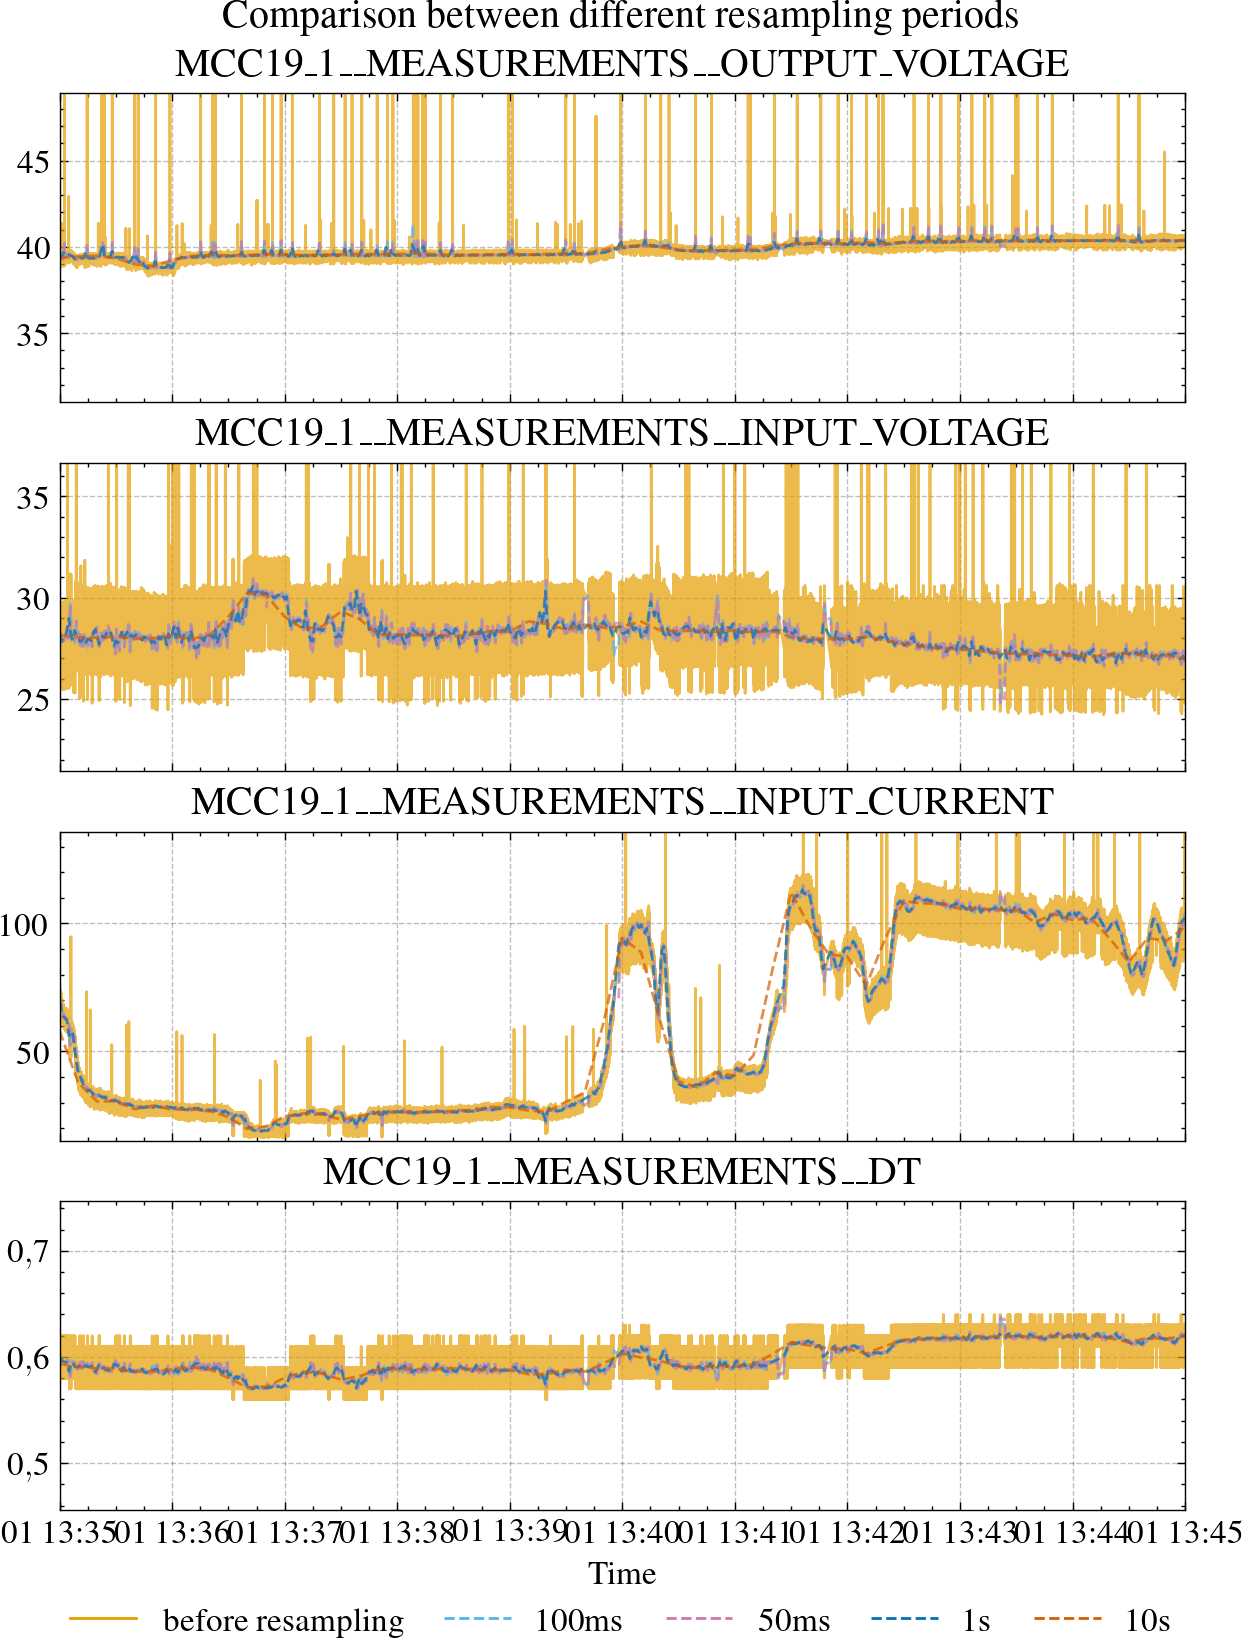

In [ ]:
import matplotlib.pyplot as plt

signals = [
    "MCC19_1__MEASUREMENTS__OUTPUT_VOLTAGE",
    "MCC19_1__MEASUREMENTS__INPUT_VOLTAGE",
    "MCC19_1__MEASUREMENTS__INPUT_CURRENT",
    "MCC19_1__MEASUREMENTS__DT",
]

t_start = pd.Timestamp("2020-02-01 13:35:00")
t_end = pd.Timestamp("2020-02-01 13:45:00")

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_combined_chunk_*.hdf5"
df1 = vaex.open(PATH1)[["timestamp", *signals]].to_pandas_df()
df1["timestamp"] = pd.to_datetime(df1["timestamp"])
df1 = df1.set_index("timestamp").sort_index()
df1 = df1.loc[(df1.index >= t_start) & (df1.index <= t_end)]

PATH2 = "../data/parsed/100ms/candump-2020-02-*.log_combined_chunk_*.hdf5"
df2 = vaex.open(PATH2)[["timestamp", *signals]].to_pandas_df()
df2["timestamp"] = pd.to_datetime(df2["timestamp"])
df2 = df2.set_index("timestamp").sort_index()
df2 = df2.loc[(df2.index >= t_start) & (df2.index <= t_end)]

PATH3 = "../data/parsed/50ms/candump-2020-02-*.log_combined_chunk_*.hdf5"
df3 = vaex.open(PATH3)[["timestamp", *signals]].to_pandas_df()
df3["timestamp"] = pd.to_datetime(df3["timestamp"])
df3 = df3.set_index("timestamp").sort_index()
df3 = df3.loc[(df3.index >= t_start) & (df3.index <= t_end)]

PATH4 = "../data/parsed/1s/candump-2020-02-*.log_combined_chunk_*.hdf5"
df4 = vaex.open(PATH4)[["timestamp", *signals]].to_pandas_df()
df4["timestamp"] = pd.to_datetime(df4["timestamp"])
df4 = df4.set_index("timestamp").sort_index()
df4 = df4.loc[(df4.index >= t_start) & (df4.index <= t_end)]

PATH5 = "../data/parsed/10s/candump-2020-02-*.log_combined_chunk_*.hdf5"
df5 = vaex.open(PATH5)[["timestamp", *signals]].to_pandas_df()
df5["timestamp"] = pd.to_datetime(df5["timestamp"])
df5 = df5.set_index("timestamp").sort_index()
df5 = df5.loc[(df5.index >= t_start) & (df5.index <= t_end)]

fig, axes = plt.subplots(
    nrows=len(signals),
    ncols=1,
    figsize=figsize(subplots=(len(signals) * 0.4, 1)),
    sharex=True,
    constrained_layout=True,
)
if len(signals) == 1:
    axes = [axes]
for ax, signal in zip(axes, signals):
    df1_s = df1.loc[t_start:t_end, signal].dropna()
    ax.plot(
        df1_s.index,
        df1_s.values,
        linestyle="solid",
        label="before resampling",
        alpha=0.7,
    )
    ax.plot(
        df2.loc[t_start:t_end].index,
        df2.loc[t_start:t_end, signal],
        linestyle="--",
        label="100ms",
        alpha=0.7,
    )
    ax.plot(
        df3.loc[t_start:t_end].index,
        df3.loc[t_start:t_end, signal],
        linestyle="--",
        label="50ms",
        alpha=0.7,
    )
    ax.plot(
        df4.loc[t_start:t_end].index,
        df4.loc[t_start:t_end, signal],
        linestyle="--",
        label="1s",
        alpha=0.7,
    )
    ax.plot(
        df5.loc[t_start:t_end].index,
        df5.loc[t_start:t_end, signal],
        linestyle="--",
        label="10s",
        alpha=0.7,
    )
    ax.set_title(signal)
    ax.grid(True, alpha=0.25)
    ax.set_xlim([t_start, t_end])
    ax.set_ylim(
        [
            df4.loc[t_start:t_end, signal].min() * 0.8,
            df4.loc[t_start:t_end, signal].max() * 1.2,
        ]
    )
axes[-1].set_xlabel("Time")
fig_save_and_show(
    filename=f"{latex_img_path}/resampling_periods_comparison2.pdf",
    save_title="Comparação entre diferentes períodos de reamostragem",
    show_title="Comparison between different resampling periods",
    ncol=5,
)

## Verification of the digital signals


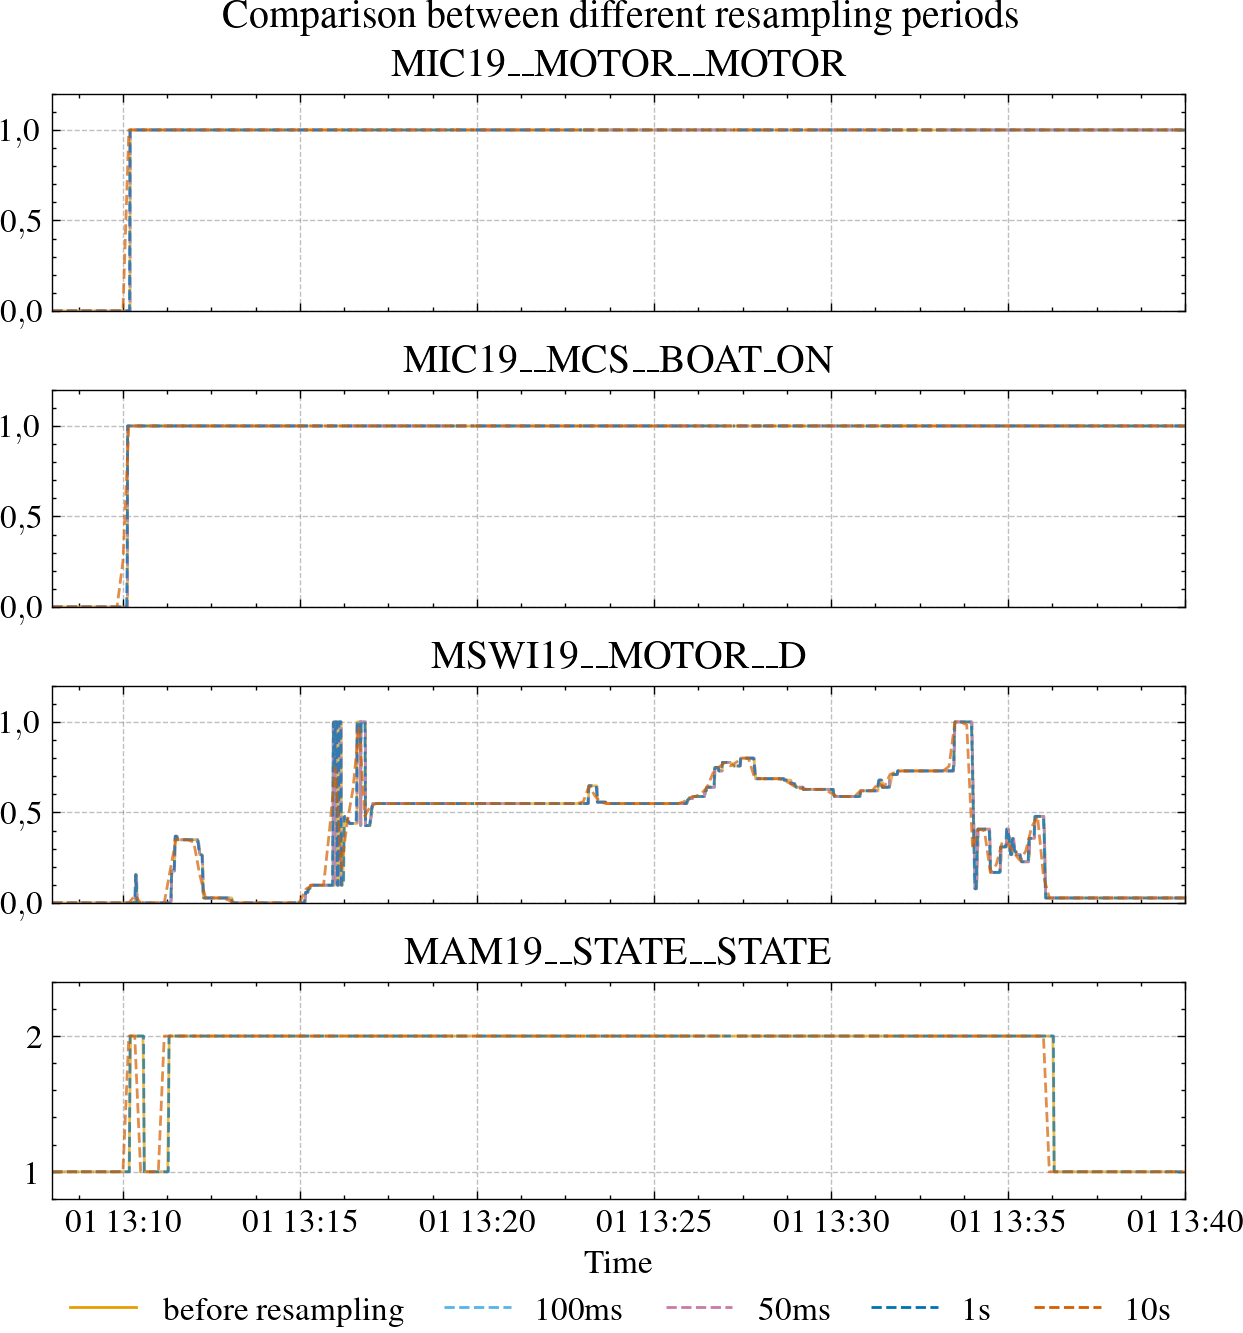

In [ ]:
import matplotlib.pyplot as plt

signals = [
    "MIC19__MOTOR__MOTOR",
    "MIC19__MCS__BOAT_ON",
    "MSWI19__MOTOR__D",
    "MAM19__STATE__STATE",
]

t_start = pd.Timestamp("2020-02-01 13:08:00")
t_end = pd.Timestamp("2020-02-01 13:40:00")

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_combined_chunk_*.hdf5"
df1 = vaex.open(PATH1)[["timestamp", *signals]].to_pandas_df()
df1["timestamp"] = pd.to_datetime(df1["timestamp"])
df1 = df1.set_index("timestamp").sort_index()
df1 = df1.loc[(df1.index >= t_start) & (df1.index <= t_end)]

PATH2 = "../data/parsed/100ms/candump-2020-02-*.log_combined_chunk_*.hdf5"
df2 = vaex.open(PATH2)[["timestamp", *signals]].to_pandas_df()
df2["timestamp"] = pd.to_datetime(df2["timestamp"])
df2 = df2.set_index("timestamp").sort_index()
df2 = df2.loc[(df2.index >= t_start) & (df2.index <= t_end)]

PATH3 = "../data/parsed/50ms/candump-2020-02-*.log_combined_chunk_*.hdf5"
df3 = vaex.open(PATH3)[["timestamp", *signals]].to_pandas_df()
df3["timestamp"] = pd.to_datetime(df3["timestamp"])
df3 = df3.set_index("timestamp").sort_index()
df3 = df3.loc[(df3.index >= t_start) & (df3.index <= t_end)]

PATH4 = "../data/parsed/1s/candump-2020-02-*.log_combined_chunk_*.hdf5"
df4 = vaex.open(PATH4)[["timestamp", *signals]].to_pandas_df()
df4["timestamp"] = pd.to_datetime(df4["timestamp"])
df4 = df4.set_index("timestamp").sort_index()
df4 = df4.loc[(df4.index >= t_start) & (df4.index <= t_end)]

PATH5 = "../data/parsed/10s/candump-2020-02-*.log_combined_chunk_*.hdf5"
df5 = vaex.open(PATH5)[["timestamp", *signals]].to_pandas_df()
df5["timestamp"] = pd.to_datetime(df5["timestamp"])
df5 = df5.set_index("timestamp").sort_index()
df5 = df5.loc[(df5.index >= t_start) & (df5.index <= t_end)]

fig, axes = plt.subplots(
    nrows=len(signals),
    ncols=1,
    figsize=figsize(subplots=(len(signals) * 0.4, 1)),
    sharex=True,
    constrained_layout=True,
)
if len(signals) == 1:
    axes = [axes]
for ax, signal in zip(axes, signals):
    df1_s = df1.loc[t_start:t_end, signal].dropna()
    ax.plot(
        df1_s.index,
        df1_s.values,
        linestyle="solid",
        label="before resampling",
        alpha=0.7,
    )
    ax.plot(
        df2.loc[t_start:t_end].index,
        df2.loc[t_start:t_end, signal],
        linestyle="--",
        label="100ms",
        alpha=0.7,
    )
    ax.plot(
        df3.loc[t_start:t_end].index,
        df3.loc[t_start:t_end, signal],
        linestyle="--",
        label="50ms",
        alpha=0.7,
    )
    ax.plot(
        df4.loc[t_start:t_end].index,
        df4.loc[t_start:t_end, signal],
        linestyle="--",
        label="1s",
        alpha=0.7,
    )
    ax.plot(
        df5.loc[t_start:t_end].index,
        df5.loc[t_start:t_end, signal],
        linestyle="--",
        label="10s",
        alpha=0.7,
    )
    ax.set_title(signal)
    ax.grid(True, alpha=0.25)
    ax.set_xlim([t_start, t_end])
    ax.set_ylim(
        [
            df4.loc[t_start:t_end, signal].min() * 0.8,
            df4.loc[t_start:t_end, signal].max() * 1.2,
        ]
    )
axes[-1].set_xlabel("Time")
fig_save_and_show(
    filename=f"{latex_img_path}/resampling_periods_comparison3.pdf",
    save_title="Comparação entre diferentes períodos de reamostragem",
    show_title="Comparison between different resampling periods",
    ncol=5,
)